# Bike Sharing Demand

## Raw Data -> Feature Engineering
In this Notebook you will find the data wrangling for the Seoul Bike Dataset. At then you will get two different datasets: 
The First Dataset **SeoulBikeData_1** it was apply the next techniques: 
 - For 'Date'('Year', 'Month', 'Day'), 'Hour' and new variable 'Weekday' was employed a cyclical transformation
 - For 'Seasons' and 'Holiday' was used One Hot Encoding
 - Drop Columns like 'Functioning Day' and 'Dew point temperature(°C)'

The second Databse **SeoulBikeData_2** was prepared dropping the less relevant columns with highest correlation between variables:
'Month_sin','Month_cos', 'Year','Day_sin', 'Day_cos', 'Winter', 'Visibility (10m)', 'Solar Radiation (MJ/m2)', 'Holiday_Yes'

## 1. Load Raw Data

In [43]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns


In [44]:
RESULTS_DIR = "data/raw"
df = pd.read_csv(f"{RESULTS_DIR}/SeoulBikeData.csv",encoding='latin1')

## 2. Encoding Data

In [45]:
df.head()

,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


In [46]:
df.dtypes

Date                          object
Rented Bike Count              int64
Hour                           int64
Temperature(°C)              float64
Humidity(%)                    int64
Wind speed (m/s)             float64
Visibility (10m)               int64
Dew point temperature(°C)    float64
Solar Radiation (MJ/m2)      float64
Rainfall(mm)                 float64
Snowfall (cm)                float64
Seasons                       object
Holiday                       object
Functioning Day               object
dtype: object

In [47]:
df.columns = df.columns.str.strip()

In [48]:
# transforming to Datetime
df["Date"] = pd.to_datetime(df["Date"],format="%d/%m/%Y")


In [49]:
df['Year'] = df.Date.dt.year
df['Year'].value_counts()

Year
2018    8016
2017     744
Name: count, dtype: int64

In [50]:
df['Month'] = df.Date.dt.month
df['Month'].value_counts()

Month
12    744
1     744
3     744
5     744
10    744
7     744
8     744
6     720
9     720
4     720
11    720
2     672
Name: count, dtype: int64

In [51]:
df['Day'] = df.Date.dt.day
df['Day'].value_counts()

Day
1     288
2     288
3     288
4     288
5     288
6     288
7     288
8     288
9     288
10    288
11    288
12    288
13    288
14    288
15    288
16    288
17    288
18    288
19    288
20    288
21    288
22    288
23    288
24    288
25    288
26    288
27    288
28    288
29    264
30    264
31    168
Name: count, dtype: int64

In [52]:
df['Weekday'] = df['Date'].dt.weekday

In [53]:
cols = ['Holiday', 'Seasons']

for col in cols:
    dummies = pd.get_dummies(
        df[col],
        prefix=col
    )

    df = pd.concat([df, dummies], axis=1)

In [54]:
cols = ['Holiday_Holiday', 'Holiday_No Holiday', 'Seasons_Autumn', 'Seasons_Spring', 'Seasons_Summer', 'Seasons_Winter', ]

df[cols] = df[cols].astype(int)

In [55]:
df.columns

Index(['Date', 'Rented Bike Count', 'Hour', 'Temperature(°C)', 'Humidity(%)',
       'Wind speed (m/s)', 'Visibility (10m)', 'Dew point temperature(°C)',
       'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)', 'Seasons',
       'Holiday', 'Functioning Day', 'Year', 'Month', 'Day', 'Weekday',
       'Holiday_Holiday', 'Holiday_No Holiday', 'Seasons_Autumn',
       'Seasons_Spring', 'Seasons_Summer', 'Seasons_Winter'],
      dtype='object')

In [56]:
df.rename(columns= {'Holiday_Holiday':'Holiday_Yes', 'Holiday_No Holiday': 'No Holiday', 'Seasons_Autumn':'Autumn', 'Seasons_Spring': 'Spring', 'Seasons_Summer': 'Summer', 'Seasons_Winter': 'Winter'}, inplace=True)

In [57]:
df = df.drop(columns=['Functioning Day', 'Dew point temperature(°C)','Seasons','Holiday'])

In [58]:
df.head()

,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Year,Month,Day,Weekday,Holiday_Yes,No Holiday,Autumn,Spring,Summer,Winter
0,2017-12-01,254,0,-5.2,37,2.2,2000,0.0,0.0,0.0,2017,12,1,4,0,1,0,0,0,1
1,2017-12-01,204,1,-5.5,38,0.8,2000,0.0,0.0,0.0,2017,12,1,4,0,1,0,0,0,1
2,2017-12-01,173,2,-6.0,39,1.0,2000,0.0,0.0,0.0,2017,12,1,4,0,1,0,0,0,1
3,2017-12-01,107,3,-6.2,40,0.9,2000,0.0,0.0,0.0,2017,12,1,4,0,1,0,0,0,1
4,2017-12-01,78,4,-6.0,36,2.3,2000,0.0,0.0,0.0,2017,12,1,4,0,1,0,0,0,1


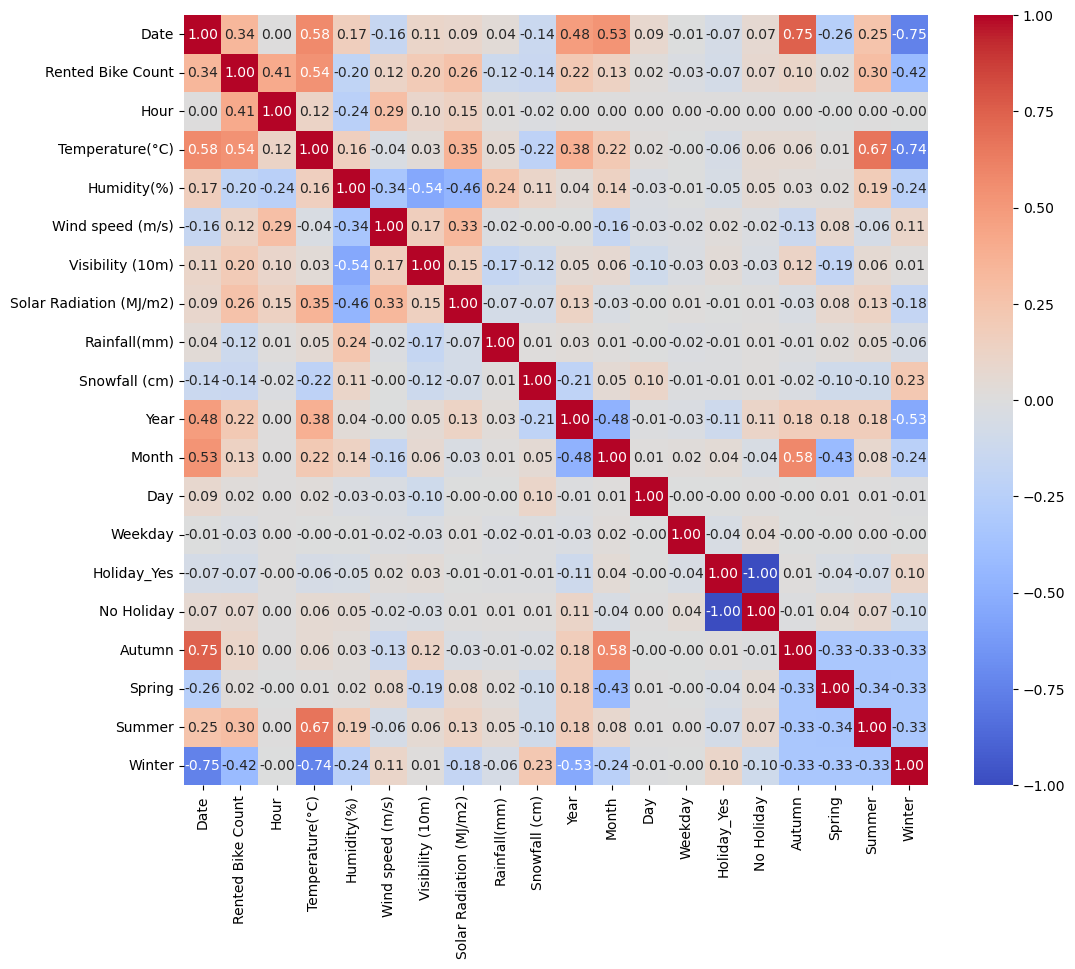

In [59]:
plt.figure(figsize=(12,10))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.show()

## Exporting Database_1

In [60]:
# exporting database
output_dir = "data/processed"
os.makedirs(output_dir, exist_ok=True)

# Save the filtered dataframe
df.to_csv(f"{output_dir}/SeoulBikeData_1.csv", index=False)

print("Exported:")
for f in os.listdir(output_dir):
    path = os.path.join(output_dir, f)
    size = os.path.getsize(path)
    print(f"  {f} ({size:,} bytes)")

Exported:
  SeoulBikeData_1.csv (627,531 bytes)
  SeoulBikeData_2.csv (1,020,928 bytes)


## Database_2

In [61]:
df['weekday_sin'] = np.sin(2 * np.pi * df['Weekday'] / 7)
df['weekday_cos'] = np.cos(2 * np.pi * df['Weekday'] / 7)

In [62]:
df['Day_sin'] = np.sin(2 * np.pi * df['Day'] / 31)
df['Day_cos'] = np.cos(2 * np.pi * df['Day'] / 31)

In [63]:
df['Hour_sin'] = np.sin(2 * np.pi * df['Hour'] / 31)
df['Hour_cos'] = np.cos(2 * np.pi * df['Hour'] / 31)

In [64]:
df = df.drop(columns=['Date','Weekday', 'Month', 'Day', 'Hour','Year','Day_sin', 'Day_cos', 'Winter', 'Visibility (10m)', 'Solar Radiation (MJ/m2)', 'Holiday_Yes'])

In [65]:
df.head()

,Rented Bike Count,Temperature(°C),Humidity(%),Wind speed (m/s),Rainfall(mm),Snowfall (cm),No Holiday,Autumn,Spring,Summer,weekday_sin,weekday_cos,Hour_sin,Hour_cos
0,254,-5.2,37,2.2,0.0,0.0,1,0,0,0,-0.433884,-0.900969,0.000000,1.000000
1,204,-5.5,38,0.8,0.0,0.0,1,0,0,0,-0.433884,-0.900969,0.201299,0.979530
2,173,-6.0,39,1.0,0.0,0.0,1,0,0,0,-0.433884,-0.900969,0.394356,0.918958
3,107,-6.2,40,0.9,0.0,0.0,1,0,0,0,-0.433884,-0.900969,0.571268,0.820763
4,78,-6.0,36,2.3,0.0,0.0,1,0,0,0,-0.433884,-0.900969,0.724793,0.688967


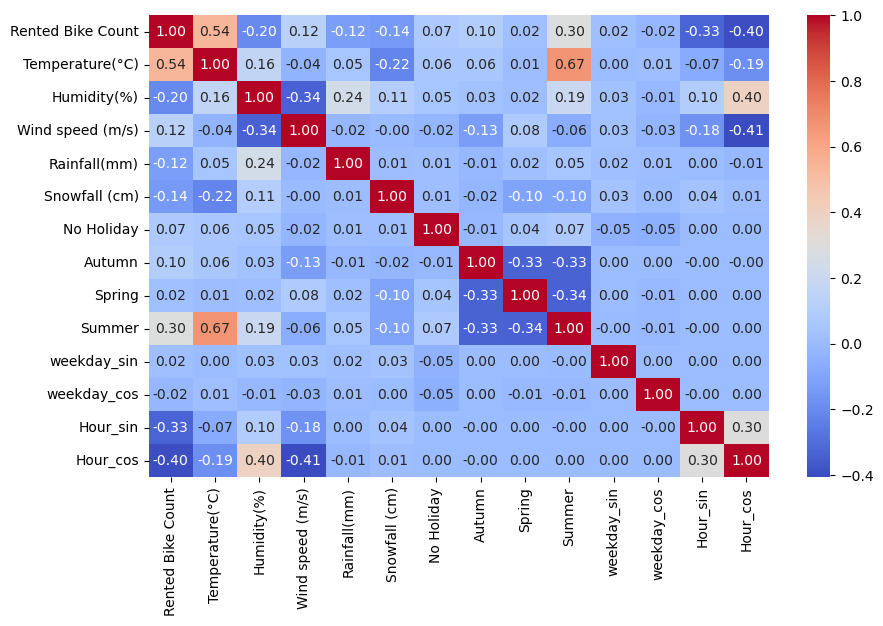

In [66]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.show()

## Exporting Database_2

In [67]:
# exporting database
output_dir = "data/processed"
os.makedirs(output_dir, exist_ok=True)

# Save the filtered dataframe
df.to_csv(f"{output_dir}/SeoulBikeData_2.csv", index=False)

print("Exported:")
for f in os.listdir(output_dir):
    path = os.path.join(output_dir, f)
    size = os.path.getsize(path)
    print(f"  {f} ({size:,} bytes)")

Exported:
  SeoulBikeData_1.csv (627,531 bytes)
  SeoulBikeData_2.csv (924,563 bytes)
